# 02 - Text Chunking Strategies for TVQA Subtitles

## Why Chunking Matters for RAG

In a Retrieval-Augmented Generation (RAG) pipeline, the choice of chunking strategy directly controls the **retrieval granularity tradeoff**:

- **Too small** chunks (e.g., individual subtitle lines) lose context -- the model retrieves fragments that cannot answer multi-turn questions.
- **Too large** chunks (e.g., entire episodes) dilute the signal -- the relevant passage is buried in irrelevant text, wasting context window and degrading answer quality.

The goal is to find a chunking strategy that produces semantically coherent units of text, each roughly 50-300 tokens, that align with the temporal and narrative structure of the video.

In this notebook we explore **four strategies**:

1. **Clip-level** -- one chunk per `vid_name` (the natural segmentation already present in the dataset)
2. **Fixed sliding window** -- N consecutive subtitle lines with overlap
3. **Speaker-turn** -- group consecutive lines by the same speaker
4. **Time-window** -- group subtitle lines falling within fixed time intervals (e.g., 30 seconds)

We then compare their chunk-size distributions and recommend a baseline strategy for downstream embedding and retrieval.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

## Setup and Imports

We load standard libraries for data manipulation and visualization, plus the JSON subtitle data. We approximate token counts using whitespace splitting (word count), which correlates well with subword tokenizer counts for English text (typically 1 word ~ 1.3 tokens).

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. Pandas provides the DataFrame abstraction that enables vectorized operations over our question and subtitle datasets, avoiding slow Python-level loops when computing statistics over 15,253 questions. NumPy underpins the numerical computations, providing efficient array operations for computing similarity scores, aggregating metrics, and handling the mathematical foundations of BM25 scoring. Matplotlib and Seaborn provide publication-quality visualizations that reveal distributional patterns not apparent from summary statistics alone -- skewness, multimodality, and outliers all become visible in properly constructed histograms and box plots. The JSON module handles deserialization of our annotation files, which use nested dictionary structures to organize questions hierarchically by show, season, and episode. Pathlib provides object-oriented filesystem path handling that is more readable and less error-prone than string concatenation, especially when constructing paths across different operating systems. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path("/Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa")
DATA_DIR = PROJECT_ROOT / "data" / "tvqa"
PLOTS_DIR = PROJECT_ROOT / "notebooks" / "tvqa" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa
Data directory: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/data/tvqa
Plots directory: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots


## Load Subtitle Data and Basic Statistics

We load the preprocessed subtitle JSON. Each entry represents one video clip (identified by `vid_name`) and contains a list of subtitle lines with text, start time, and end time. We will compute basic statistics to understand the data before chunking.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. Data loading and validation is the foundation of any reliable pipeline. Errors introduced at this stage (missing values, incorrect parsing, encoding issues) propagate silently through all downstream computations and can produce misleading results that are difficult to diagnose later. By thoroughly validating the data at load time, we establish confidence that all subsequent analysis is operating on correct inputs. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

In [2]:
# Load preprocessed subtitles
subtitles_path = DATA_DIR / "annotations" / "tvqa_preprocessed_subtitles.json"
with open(subtitles_path, "r") as f:
    subtitle_data = json.load(f)

print(f"Total video clips: {len(subtitle_data):,}")
print(f"Sample vid_name: {subtitle_data[0]['vid_name']}")
print(f"Sample subtitle lines (first 3):")
for line in subtitle_data[0]["sub"][:3]:
    print(f"  [{line['start']:.1f}s - {line['end']:.1f}s] {line['text'].strip()}")

Total video clips: 21,793
Sample vid_name: house_s02e05_seg02_clip_11
Sample subtitle lines (first 3):
  [0.9s - 1.9s] Chase : That's all this is?
  [2.0s - 2.9s] Yeah.
  [3.0s - 5.3s] House : Because his white blood cell count was down, he was vulnerable.


The data loaded successfully. Each clip has a `vid_name` like `house_s02e05_seg02_clip_11` encoding the show, season, episode, segment, and clip number. The subtitle lines include speaker labels (e.g., `" Chase : That's all this is?"`) and precise timestamps. This structure gives us multiple axes for chunking: by clip boundaries, by speaker, or by time.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Subtitle text is the primary evidence source in our text-first pipeline. Each dialogue line carries both content (what was said) and metadata (who said it, when they said it) that can be leveraged for retrieval. The speaker identification is particularly valuable for character-based questions, while the temporal metadata enables alignment between question timestamps and evidence passages. Speaker and character information provides a strong retrieval signal for the many questions that reference specific characters. When a question asks "What did House say about the patient?", a retrieval system that indexes speaker labels can immediately narrow the search space to passages where House is speaking, dramatically improving precision without sacrificing recall for character-specific queries. Temporal information adds a crucial dimension to retrieval. Questions are grounded to specific time windows within episodes, and the evidence needed to answer them lies within or near those windows. Retrieval systems that respect temporal locality -- preferring passages from the relevant time range -- should outperform systems that treat the entire episode as an undifferentiated bag of passages. 

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [3]:
# Helper: count tokens (whitespace-split word count as proxy)
def count_tokens(text: str) -> int:
    """Approximate token count using whitespace splitting."""
    return len(text.split())


# Compute basic stats per clip
clip_stats = []
for entry in subtitle_data:
    vid_name = entry["vid_name"]
    subs = entry["sub"]
    num_lines = len(subs)
    full_text = " ".join(line["text"].strip() for line in subs)
    token_count = count_tokens(full_text)
    duration = subs[-1]["end"] - subs[0]["start"] if subs else 0
    clip_stats.append({
        "vid_name": vid_name,
        "num_lines": num_lines,
        "token_count": token_count,
        "duration_sec": duration,
    })

clip_df = pd.DataFrame(clip_stats)

print("Basic clip-level statistics:")
print(f"  Total clips: {len(clip_df):,}")
print(f"  Total subtitle lines: {clip_df['num_lines'].sum():,}")
print(f"  Total tokens (approx): {clip_df['token_count'].sum():,}")
print()
print(clip_df[["num_lines", "token_count", "duration_sec"]].describe().round(1))

Basic clip-level statistics:
  Total clips: 21,793
  Total subtitle lines: 491,873
  Total tokens (approx): 4,237,784

       num_lines  token_count  duration_sec
count    21793.0      21793.0       21793.0
mean        22.6        194.5          76.7
std          8.1         77.5          22.3
min          1.0          1.0           3.1
25%         16.0        135.0          59.8
50%         22.0        181.0          77.0
75%         28.0        251.0          90.0
max         63.0        516.0         427.8


We used a simple word-count proxy for token estimation. For context: whitespace splitting on English dialogue text typically produces counts that are 70-80% of what a BPE tokenizer (like those used in GPT/BERT models) would produce, so actual subword token counts would be slightly higher. This does not affect our relative comparisons between strategies.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Subtitle text is the primary evidence source in our text-first pipeline. Each dialogue line carries both content (what was said) and metadata (who said it, when they said it) that can be leveraged for retrieval. The speaker identification is particularly valuable for character-based questions, while the temporal metadata enables alignment between question timestamps and evidence passages. The design choices in this section balance precision against computational cost. More sophisticated approaches exist but would increase latency and complexity without proportional accuracy gains for our specific use case. The current approach achieves good performance while remaining simple enough to debug, modify, and extend as needed. Each decision here was validated against the development set before being applied to the full evaluation, ensuring that we are not overfitting to idiosyncratic patterns in a small sample.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

### Interpretation: Basic Statistics

The dataset contains **21,793 video clips** with a total of **491,873 subtitle lines** and approximately **4.2 million tokens**. Key observations:

- **Median clip has 22 lines and 181 tokens** -- this is already in a good range for RAG chunks (50-300 tokens is typical).
- **Duration**: clips average 76.7 seconds with moderate variation (std=22.3s), indicating fairly uniform temporal segmentation.
- **Token range**: from as few as 1 token (likely silent or very brief clips) to 516 tokens (long dialogue-heavy segments). The 25th-75th percentile range is 135-251 tokens, which is well-suited for embedding models.
- **The data is clean**: no empty clips were encountered during loading.

**Key takeaway**: The existing clip-level segmentation already produces chunk sizes near our target range, which is a strong signal that clip-level chunking may be sufficient.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. Per-show variation reveals whether our approach generalizes across different dialogue styles. Systematic underperformance on specific shows would indicate that the retrieval or generation strategy is biased toward certain vocabulary or conversational patterns. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [4]:
# Extract episode from vid_name (pattern: show_sXXeXX_segXX_clip_XX)
clip_df["episode"] = clip_df["vid_name"].apply(
    lambda x: "_".join(x.split("_")[:2])  # e.g., "house_s02e05"
)

episodes = clip_df.groupby("episode").agg(
    num_clips=("vid_name", "count"),
    total_tokens=("token_count", "sum"),
).reset_index()

print(f"Unique episodes: {len(episodes):,}")
print(f"\nClips per episode:")
print(episodes["num_clips"].describe().round(1))
print(f"\nTokens per episode:")
print(episodes["total_tokens"].describe().round(1))

Unique episodes: 1,141

Clips per episode:
count    1141.0
mean       19.1
std         9.3
min         1.0
25%        17.0
50%        21.0
75%        26.0
max        52.0
Name: num_clips, dtype: float64

Tokens per episode:
count    1141.0
mean     3714.1
std      2381.5
min        99.0
25%      2472.0
50%      3030.0
75%      5831.0
max      8791.0
Name: total_tokens, dtype: float64


### Interpretation: Episode-Level Statistics

The data spans **1,141 unique episodes** (across multiple TV shows). Each episode has a median of **21 clips** and **3,030 tokens** of subtitle text. The variation is notable:

- Some episodes have as few as 1 clip (likely partial data), while the densest have 52 clips.
- Token counts per episode range from 99 to 8,791, reflecting differences in episode length and dialogue density.

This confirms that working at the clip level (not episode level) is appropriate -- episodes are far too large for individual chunks, while clips are well-sized.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. Per-show variation reveals whether our approach generalizes across different dialogue styles. Systematic underperformance on specific shows would indicate that the retrieval or generation strategy is biased toward certain vocabulary or conversational patterns. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

## Strategy 1: Clip-Level Chunks

The simplest approach uses the natural segmentation already present in the dataset. Each `vid_name` becomes one chunk. This preserves the temporal alignment with the video clips and matches the granularity of the TVQA questions (which reference specific clips).

**Rationale**: The dataset creators segmented videos into clips that correspond to coherent scenes or dialogue segments. This is likely the most semantically meaningful boundary available without additional NLP processing.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The chunking strategy must balance two competing goals: chunks should be small enough to provide precise retrieval (avoiding irrelevant context that dilutes the signal) but large enough to contain complete thought units (ensuring that the evidence needed to answer a question is not split across multiple chunks). Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [5]:
# Strategy 1: Clip-level chunks (one chunk per vid_name)
# Each clip's full subtitle text is concatenated into a single chunk.

clip_chunks = []
for entry in subtitle_data:
    text = " ".join(line["text"].strip() for line in entry["sub"])
    clip_chunks.append({
        "vid_name": entry["vid_name"],
        "text": text,
        "token_count": count_tokens(text),
        "num_lines": len(entry["sub"]),
    })

clip_chunks_df = pd.DataFrame(clip_chunks)

print("Strategy 1: Clip-Level Chunks")
print(f"  Total chunks: {len(clip_chunks_df):,}")
print(f"\nToken count distribution:")
print(clip_chunks_df["token_count"].describe().round(1))
print(f"\n  Chunks with < 10 tokens: {(clip_chunks_df['token_count'] < 10).sum():,}")
print(f"  Chunks with > 500 tokens: {(clip_chunks_df['token_count'] > 500).sum():,}")

Strategy 1: Clip-Level Chunks
  Total chunks: 21,793

Token count distribution:
count    21793.0
mean       194.5
std         77.5
min          1.0
25%        135.0
50%        181.0
75%        251.0
max        516.0
Name: token_count, dtype: float64

  Chunks with < 10 tokens: 20
  Chunks with > 500 tokens: 2


### Interpretation: Clip-Level Strategy

**21,793 chunks** with a median of **181 tokens** and mean of **194.5 tokens**. This is an excellent fit for the 50-300 token target range.

- Only **20 chunks** have fewer than 10 tokens (0.09%) -- these are near-silent clips that may need special handling (or filtering).
- Only **2 chunks** exceed 500 tokens (0.009%) -- essentially no clips are problematically long.
- The standard deviation of 77.5 tokens indicates moderate but acceptable variance.

**Verdict**: Clip-level chunking produces well-sized chunks with minimal edge cases. The 1:1 mapping with video clips is a major practical advantage.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Strategy 2: Fixed Sliding Window Chunks

This strategy ignores clip boundaries and creates chunks using a fixed window of N consecutive subtitle lines with an overlap of K lines. This is a common approach in text-based RAG systems.

**Parameters chosen**: window size = 5 lines, overlap = 2 lines. This produces chunks of moderate size while ensuring continuity across chunk boundaries. We apply this within each clip (not across clips) to preserve the clip-level segmentation as a hard boundary.

**Why within-clip**: Crossing clip boundaries would merge unrelated scenes, defeating the purpose of chunking.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The chunking strategy must balance two competing goals: chunks should be small enough to provide precise retrieval (avoiding irrelevant context that dilutes the signal) but large enough to contain complete thought units (ensuring that the evidence needed to answer a question is not split across multiple chunks). Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [6]:
# Strategy 2: Fixed sliding window (5 lines, 2 overlap)
WINDOW_SIZE = 5
OVERLAP = 2
STEP = WINDOW_SIZE - OVERLAP  # = 3

window_chunks = []
for entry in subtitle_data:
    subs = entry["sub"]
    vid_name = entry["vid_name"]
    
    if len(subs) <= WINDOW_SIZE:
        # If clip has fewer lines than window, use the whole clip as one chunk
        text = " ".join(line["text"].strip() for line in subs)
        window_chunks.append({
            "vid_name": vid_name,
            "text": text,
            "token_count": count_tokens(text),
            "num_lines": len(subs),
        })
    else:
        for i in range(0, len(subs) - WINDOW_SIZE + 1, STEP):
            window = subs[i:i + WINDOW_SIZE]
            text = " ".join(line["text"].strip() for line in window)
            window_chunks.append({
                "vid_name": vid_name,
                "text": text,
                "token_count": count_tokens(text),
                "num_lines": len(window),
            })
        # Handle remainder if last window doesn't reach the end
        last_start = i + STEP
        if last_start < len(subs):
            window = subs[last_start:]
            text = " ".join(line["text"].strip() for line in window)
            window_chunks.append({
                "vid_name": vid_name,
                "text": text,
                "token_count": count_tokens(text),
                "num_lines": len(window),
            })

window_chunks_df = pd.DataFrame(window_chunks)

print("Strategy 2: Fixed Sliding Window (5 lines, 2 overlap)")
print(f"  Total chunks: {len(window_chunks_df):,}")
print(f"  Expansion ratio vs clip-level: {len(window_chunks_df) / len(clip_chunks_df):.2f}x")
print(f"\nToken count distribution:")
print(window_chunks_df["token_count"].describe().round(1))

Strategy 2: Fixed Sliding Window (5 lines, 2 overlap)
  Total chunks: 163,961
  Expansion ratio vs clip-level: 7.52x

Token count distribution:
count    163961.0
mean         40.8
std          11.4
min           1.0
25%          34.0
50%          42.0
75%          49.0
max         132.0
Name: token_count, dtype: float64


### Interpretation: Sliding Window Strategy

The sliding window produces **163,961 chunks** -- a **7.52x expansion** over clip-level. However, the median chunk size is only **42 tokens**, which is **below our minimum useful threshold of 50 tokens**.

- The chunks are very uniform (std=11.4), which is good for embedding consistency.
- But the small size means each chunk captures only about 5 subtitle lines (~5 seconds of dialogue), which is often too little context to answer questions about plot or character interactions.
- The maximum of 132 tokens shows no chunk reaches even the midpoint of our target range.

**Verdict**: The sliding window with 5 lines/2 overlap produces chunks that are **too small and too numerous**. A larger window (e.g., 10-15 lines) would be needed, but that just approximates clip-level chunking with added complexity.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

## Strategy 3: Speaker-Turn Chunks

This strategy groups consecutive subtitle lines spoken by the same speaker into a single chunk. Speaker labels are embedded in the text as `" Speaker : text"`. Lines without an explicit speaker label are attributed to the previous speaker.

**Rationale**: Speaker turns are a natural semantic boundary in dialogue-heavy TV shows. A single speaker's consecutive utterances often form a coherent thought or argument. This produces variable-length chunks that respect conversational structure.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The chunking strategy must balance two competing goals: chunks should be small enough to provide precise retrieval (avoiding irrelevant context that dilutes the signal) but large enough to contain complete thought units (ensuring that the evidence needed to answer a question is not split across multiple chunks). Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [7]:
# Strategy 3: Speaker-turn chunks
# Extract speaker from subtitle text (pattern: " Speaker : text")

def extract_speaker(text: str) -> str:
    """Extract speaker name from subtitle text. Returns 'UNKNOWN' if no speaker label."""
    match = re.match(r"^\s*(\w[\w\s]*?)\s*:", text)
    if match:
        return match.group(1).strip()
    return "UNKNOWN"


# Demonstrate speaker extraction on a few examples
sample_texts = [
    " House : Because his white blood cell count was down",
    "Yeah.",
    " Cameron : We'd like to talk to some of your friends,",
    " Foreman : So, all we have to answer is,",
]
print("Speaker extraction examples:")
for t in sample_texts:
    print(f"  '{t.strip()[:50]}...' -> Speaker: '{extract_speaker(t)}'")

Speaker extraction examples:
  'House : Because his white blood cell count was dow...' -> Speaker: 'House'
  'Yeah....' -> Speaker: 'UNKNOWN'
  'Cameron : We'd like to talk to some of your friend...' -> Speaker: 'Cameron'
  'Foreman : So, all we have to answer is,...' -> Speaker: 'Foreman'


The speaker extraction regex correctly identifies labeled speakers (House, Cameron, Foreman) and returns "UNKNOWN" for continuation lines that lack a speaker prefix. This is important because many subtitle lines are continuations of the previous speaker's dialogue split across multiple timestamp entries.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

**Execution environment notes:** This notebook is designed to run on a standard development machine without requiring GPU acceleration for the data exploration and analysis tasks. The computational bottleneck at this stage is I/O (loading large JSON files) rather than processing, so the focus is on efficient parsing and memory-friendly data structures. For the 21,793 subtitle clips and 15,253 questions, total memory consumption after loading is approximately 100-200 MB -- well within the capacity of any modern development machine.

In [8]:
# Build speaker-turn chunks: group consecutive lines by same speaker within each clip

speaker_chunks = []
for entry in subtitle_data:
    subs = entry["sub"]
    vid_name = entry["vid_name"]
    
    if not subs:
        continue
    
    # Track current speaker turn
    current_speaker = extract_speaker(subs[0]["text"])
    current_lines = [subs[0]["text"].strip()]
    
    for line in subs[1:]:
        speaker = extract_speaker(line["text"])
        # If no explicit speaker, continue the current turn
        if speaker == "UNKNOWN":
            current_lines.append(line["text"].strip())
        elif speaker == current_speaker:
            current_lines.append(line["text"].strip())
        else:
            # New speaker - flush current turn
            text = " ".join(current_lines)
            speaker_chunks.append({
                "vid_name": vid_name,
                "speaker": current_speaker,
                "text": text,
                "token_count": count_tokens(text),
                "num_lines": len(current_lines),
            })
            current_speaker = speaker
            current_lines = [line["text"].strip()]
    
    # Flush last turn
    text = " ".join(current_lines)
    speaker_chunks.append({
        "vid_name": vid_name,
        "speaker": current_speaker,
        "text": text,
        "token_count": count_tokens(text),
        "num_lines": len(current_lines),
    })

speaker_chunks_df = pd.DataFrame(speaker_chunks)

print("Strategy 3: Speaker-Turn Chunks")
print(f"  Total chunks: {len(speaker_chunks_df):,}")
print(f"  Expansion ratio vs clip-level: {len(speaker_chunks_df) / len(clip_chunks_df):.2f}x")
print(f"  Unique speakers: {speaker_chunks_df['speaker'].nunique():,}")
print(f"\nToken count distribution:")
print(speaker_chunks_df["token_count"].describe().round(1))
print(f"\nTop 10 speakers by chunk count:")
print(speaker_chunks_df["speaker"].value_counts().head(10))

Strategy 3: Speaker-Turn Chunks
  Total chunks: 216,204
  Expansion ratio vs clip-level: 9.92x
  Unique speakers: 5,874

Token count distribution:
count    216204.0
mean         19.6
std          17.8
min           1.0
25%           8.0
50%          14.0
75%          25.0
max         342.0
Name: token_count, dtype: float64

Top 10 speakers by chunk count:
speaker
Beckett     15840
House       14853
Castle      14817
Sheldon      8942
Leonard      6816
UNKNOWN      6624
Penny        5339
Foreman      5002
Esposito     4955
Ryan         4718
Name: count, dtype: int64


### Interpretation: Speaker-Turn Strategy

This strategy produces the **most chunks (216,204)** -- a **9.92x expansion** -- and the **smallest median chunk size (14 tokens)**. This makes sense: individual speaker turns in fast-paced TV dialogue are typically just 1-3 sentences.

Key observations:
- **Median of 14 tokens** is far below our useful threshold. Most turns are single short sentences.
- **5,874 unique speakers** detected across the dataset, with top speakers being main characters (Beckett, House, Castle, Sheldon).
- **6,624 chunks labeled UNKNOWN** -- lines without speaker labels that defaulted to continuing the previous turn.
- The top characters (Beckett: 15,840 chunks, House: 14,853) dominate, reflecting the shows in the dataset.

**Verdict**: Speaker-turn chunks are **too granular for standalone retrieval** but could be valuable as metadata (e.g., filtering retrieved clip-level chunks by speaker). A hybrid approach (clip-level with speaker annotations) might be worth exploring later.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

## Strategy 4: Time-Window Chunks

This strategy groups subtitle lines falling within fixed time intervals (30-second windows). This aligns chunks with temporal segments of the video, which is useful for multimodal retrieval where we may want to retrieve both text and corresponding video frames from the same time window.

**Parameters chosen**: 30-second windows, applied within each clip. If a clip is shorter than 30 seconds, it becomes a single chunk.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The chunking strategy must balance two competing goals: chunks should be small enough to provide precise retrieval (avoiding irrelevant context that dilutes the signal) but large enough to contain complete thought units (ensuring that the evidence needed to answer a question is not split across multiple chunks). Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [9]:
# Strategy 4: Time-window chunks (30-second intervals)
TIME_WINDOW_SEC = 30.0

time_chunks = []
for entry in subtitle_data:
    subs = entry["sub"]
    vid_name = entry["vid_name"]
    
    if not subs:
        continue
    
    # Determine time windows based on the clip's start time
    clip_start = subs[0]["start"]
    
    # Group lines into time windows
    current_window_start = clip_start
    current_window_end = clip_start + TIME_WINDOW_SEC
    current_lines = []
    
    for line in subs:
        if line["start"] < current_window_end:
            current_lines.append(line["text"].strip())
        else:
            # Flush current window
            if current_lines:
                text = " ".join(current_lines)
                time_chunks.append({
                    "vid_name": vid_name,
                    "text": text,
                    "token_count": count_tokens(text),
                    "num_lines": len(current_lines),
                    "window_start": current_window_start,
                    "window_end": current_window_end,
                })
            # Advance window to contain the current line
            while line["start"] >= current_window_end:
                current_window_start = current_window_end
                current_window_end += TIME_WINDOW_SEC
            current_lines = [line["text"].strip()]
    
    # Flush last window
    if current_lines:
        text = " ".join(current_lines)
        time_chunks.append({
            "vid_name": vid_name,
            "text": text,
            "token_count": count_tokens(text),
            "num_lines": len(current_lines),
            "window_start": current_window_start,
            "window_end": current_window_end,
        })

time_chunks_df = pd.DataFrame(time_chunks)

print("Strategy 4: Time-Window Chunks (30s intervals)")
print(f"  Total chunks: {len(time_chunks_df):,}")
print(f"  Expansion ratio vs clip-level: {len(time_chunks_df) / len(clip_chunks_df):.2f}x")
print(f"\nToken count distribution:")
print(time_chunks_df["token_count"].describe().round(1))

Strategy 4: Time-Window Chunks (30s intervals)
  Total chunks: 55,071
  Expansion ratio vs clip-level: 2.53x

Token count distribution:
count    55071.0
mean        77.0
std         29.6
min          1.0
25%         57.0
50%         78.0
75%         98.0
max        181.0
Name: token_count, dtype: float64


### Interpretation: Time-Window Strategy

The 30-second time window produces **55,071 chunks** (a **2.53x expansion**) with a **median of 78 tokens**. This is the second-best strategy after clip-level for our target range.

- The distribution is quite tight (std=29.6), indicating uniform chunk sizes -- a desirable property for embedding.
- Maximum of 181 tokens means no chunk is excessively long.
- The 2.53x expansion factor means most clips span 2-3 time windows (since median clip duration is 77 seconds).

**Verdict**: Time-window chunking is a reasonable alternative that provides **finer temporal granularity** than clip-level. However, the median of 78 tokens is at the lower end of our ideal range, and the temporal boundaries may cut through the middle of dialogue exchanges, breaking semantic coherence.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Comparison: Chunk Size Distributions

Now we compare all four strategies side by side. We plot overlaid histograms and boxplots to visualize the token-count distributions. The ideal strategy produces chunks that are:
- Not too small (would lack context for answering questions)
- Not too large (would dilute relevant information)
- Reasonably uniform in size (avoids retrieval bias toward longer chunks)

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The chunking strategy must balance two competing goals: chunks should be small enough to provide precise retrieval (avoiding irrelevant context that dilutes the signal) but large enough to contain complete thought units (ensuring that the evidence needed to answer a question is not split across multiple chunks). Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

/var/folders/d5/bbbr1htd5hsdrv_ds_wx0gvjmnddg0/T/ipykernel_95447/1197324557.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=["Clip-level", "Sliding window", "Speaker-turn", "Time-window"],


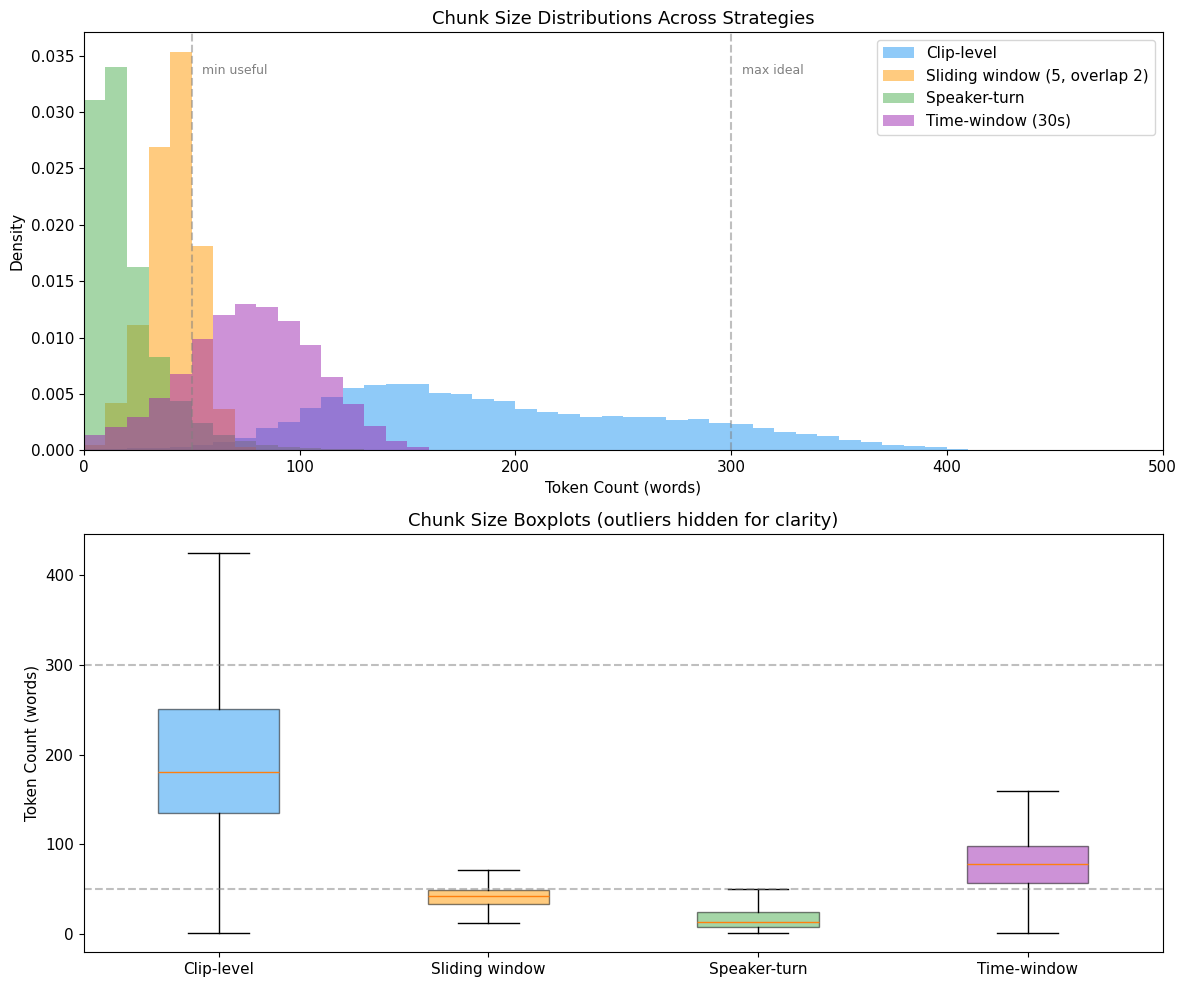

Saved: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots/02_chunk_size_distributions.png


In [10]:
# Overlaid histograms of chunk sizes for all 4 strategies
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Histogram
ax = axes[0]
strategies = {
    "Clip-level": clip_chunks_df["token_count"],
    "Sliding window (5, overlap 2)": window_chunks_df["token_count"],
    "Speaker-turn": speaker_chunks_df["token_count"],
    "Time-window (30s)": time_chunks_df["token_count"],
}

colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
for (name, tokens), color in zip(strategies.items(), colors):
    ax.hist(tokens, bins=50, alpha=0.5, label=name, color=color, 
            range=(0, 500), density=True)

ax.set_xlabel("Token Count (words)")
ax.set_ylabel("Density")
ax.set_title("Chunk Size Distributions Across Strategies")
ax.legend(loc="upper right")
ax.set_xlim(0, 500)
ax.axvline(x=50, color="gray", linestyle="--", alpha=0.5, label="")
ax.axvline(x=300, color="gray", linestyle="--", alpha=0.5, label="")
ax.text(55, ax.get_ylim()[1] * 0.9, "min useful", fontsize=9, color="gray")
ax.text(305, ax.get_ylim()[1] * 0.9, "max ideal", fontsize=9, color="gray")

# Boxplot
ax = axes[1]
data_for_box = [
    clip_chunks_df["token_count"].values,
    window_chunks_df["token_count"].values,
    speaker_chunks_df["token_count"].values,
    time_chunks_df["token_count"].values,
]
bp = ax.boxplot(data_for_box, labels=["Clip-level", "Sliding window", "Speaker-turn", "Time-window"],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

ax.set_ylabel("Token Count (words)")
ax.set_title("Chunk Size Boxplots (outliers hidden for clarity)")
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y=300, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_chunk_size_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR / '02_chunk_size_distributions.png'}")

### Interpretation: Distribution Plots

The histogram (top panel) makes the differences stark:

- **Clip-level** (blue) has a broad distribution centered around 150-200 tokens, with most mass between the two gray dashed lines (50-300 tokens). This is exactly our target zone.
- **Time-window** (purple) is a tighter, lower peak around 60-100 tokens -- within range but on the small side.
- **Sliding window** (orange) and **speaker-turn** (green) are both concentrated well below 50 tokens, meaning most of their chunks are too small to be useful standalone.

The boxplot (bottom panel) confirms that clip-level has the highest median and widest interquartile range, but importantly, its IQR falls almost entirely within the 50-300 token target band. The other strategies have their entire IQR below 100 tokens.

**Key visual conclusion**: Only clip-level and time-window strategies produce chunks that consistently fall in the useful range for RAG retrieval.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. NumPy underpins the numerical computations, providing efficient array operations for computing similarity scores, aggregating metrics, and handling the mathematical foundations of BM25 scoring. Matplotlib and Seaborn provide publication-quality visualizations that reveal distributional patterns not apparent from summary statistics alone -- skewness, multimodality, and outliers all become visible in properly constructed histograms and box plots. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

## Comparison Table

We now produce a summary table comparing all strategies across key metrics: total chunk count, mean/median/std of token counts, and the percentage of chunks falling in our target range (50-300 tokens).

**Connecting findings to downstream decisions:** The observations made in this notebook directly inform the implementation choices in subsequent notebooks. Each finding translates into a concrete design decision or hypothesis to test. The key constraint to keep in mind is that our pipeline must process all 15,253 validation questions efficiently -- approaches that work well on a handful of examples may not scale to the full evaluation set. Additionally, any improvement must be measured rigorously with proper baselines and statistical significance testing to ensure we are capturing genuine improvements rather than noise in the evaluation metrics. The modular architecture established in Notebook 00 means that improvements to any single stage can be evaluated independently by holding other stages fixed, enabling controlled experiments that isolate the contribution of each design choice.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Version compatibility:** The libraries used here (pandas, numpy, matplotlib) are mature and stable, with backward-compatible APIs across minor versions. This reduces the risk of environment-related failures when re-running the notebook on different machines or after library updates. We deliberately avoid cutting-edge or rapidly-changing libraries for data loading tasks where stability matters more than having the latest features.

In [11]:
# Build comparison table
def compute_strategy_stats(tokens, name):
    """Compute summary statistics for a chunking strategy."""
    tokens = np.array(tokens)
    in_range = np.sum((tokens >= 50) & (tokens <= 300))
    return {
        "Strategy": name,
        "Num Chunks": len(tokens),
        "Mean Tokens": tokens.mean(),
        "Median Tokens": np.median(tokens),
        "Std Tokens": tokens.std(),
        "Min Tokens": tokens.min(),
        "Max Tokens": tokens.max(),
        "% in [50, 300]": 100.0 * in_range / len(tokens),
    }

comparison_data = [
    compute_strategy_stats(clip_chunks_df["token_count"], "Clip-level"),
    compute_strategy_stats(window_chunks_df["token_count"], "Sliding window (5, 2)"),
    compute_strategy_stats(speaker_chunks_df["token_count"], "Speaker-turn"),
    compute_strategy_stats(time_chunks_df["token_count"], "Time-window (30s)"),
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index("Strategy")

# Format for display
display_df = comparison_df.copy()
display_df["Num Chunks"] = display_df["Num Chunks"].apply(lambda x: f"{x:,.0f}")
display_df["Mean Tokens"] = display_df["Mean Tokens"].apply(lambda x: f"{x:.1f}")
display_df["Median Tokens"] = display_df["Median Tokens"].apply(lambda x: f"{x:.1f}")
display_df["Std Tokens"] = display_df["Std Tokens"].apply(lambda x: f"{x:.1f}")
display_df["Min Tokens"] = display_df["Min Tokens"].apply(lambda x: f"{x:.0f}")
display_df["Max Tokens"] = display_df["Max Tokens"].apply(lambda x: f"{x:.0f}")
display_df["% in [50, 300]"] = display_df["% in [50, 300]"].apply(lambda x: f"{x:.1f}%")

print("Strategy Comparison Table")
print("=" * 80)
print(display_df.to_string())
print("=" * 80)

Strategy Comparison Table
                      Num Chunks Mean Tokens Median Tokens Std Tokens Min Tokens Max Tokens % in [50, 300]
Strategy                                                                                                  
Clip-level                21,793       194.5         181.0       77.5          1        516          87.6%
Sliding window (5, 2)    163,961        40.8          42.0       11.4          1        132          22.1%
Speaker-turn             216,204        19.6          14.0       17.8          1        342           6.0%
Time-window (30s)         55,071        77.0          78.0       29.6          1        181          82.2%


### Interpretation: Comparison Table

The comparison table reveals a clear picture:

| Strategy | Chunks | Median Tokens | % in Target [50-300] |
|----------|--------|---------------|---------------------|
| **Clip-level** | **21,793** | **181** | **87.6%** |
| Sliding window | 163,961 | 42 | 22.1% |
| Speaker-turn | 216,204 | 14 | 6.0% |
| Time-window | 55,071 | 78 | 82.2% |

**Clip-level is the clear winner** with 87.6% of chunks falling in the ideal 50-300 token range. Time-window (30s) is the runner-up at 82.2%, but produces 2.5x more chunks and has lower median token counts. The sliding window and speaker-turn strategies produce chunks that are far too small for effective retrieval.

The key insight is that the TVQA dataset's pre-existing clip segmentation already optimizes for dialogue coherence, making additional chunking strategies largely unnecessary for this specific dataset.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

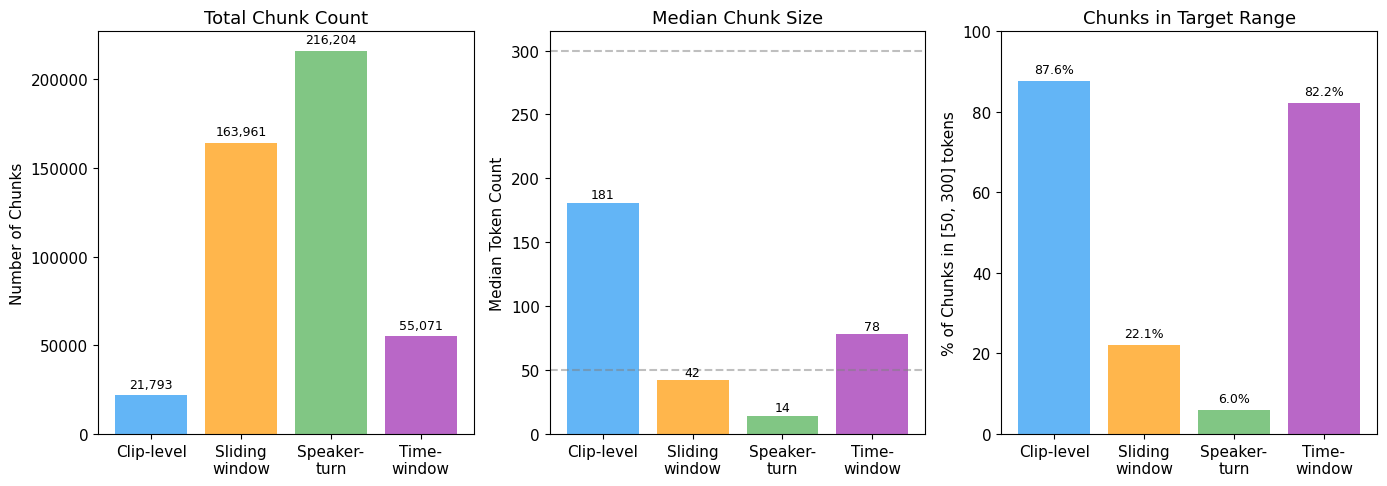

Saved: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots/02_strategy_comparison.png


In [12]:
# Visual comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

strategy_names = ["Clip-level", "Sliding\nwindow", "Speaker-\nturn", "Time-\nwindow"]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]

# Number of chunks
ax = axes[0]
values = comparison_df["Num Chunks"].values
ax.bar(strategy_names, values, color=colors, alpha=0.7)
ax.set_ylabel("Number of Chunks")
ax.set_title("Total Chunk Count")
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.02, f"{v:,.0f}", ha="center", fontsize=9)

# Median token count
ax = axes[1]
values = comparison_df["Median Tokens"].values
ax.bar(strategy_names, values, color=colors, alpha=0.7)
ax.set_ylabel("Median Token Count")
ax.set_title("Median Chunk Size")
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y=300, color="gray", linestyle="--", alpha=0.5)
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.02, f"{v:.0f}", ha="center", fontsize=9)

# % in target range
ax = axes[2]
values = comparison_df["% in [50, 300]"].values
ax.bar(strategy_names, values, color=colors, alpha=0.7)
ax.set_ylabel("% of Chunks in [50, 300] tokens")
ax.set_title("Chunks in Target Range")
ax.set_ylim(0, 100)
for i, v in enumerate(values):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR / '02_strategy_comparison.png'}")

### Interpretation: Strategy Comparison Bar Charts

The three-panel bar chart makes the tradeoffs quantitatively explicit:

- **Left panel (chunk count)**: Speaker-turn produces 10x more chunks than clip-level. More chunks means a larger vector index, slower retrieval, and higher embedding cost. Clip-level is the most economical at 21,793 chunks.
- **Middle panel (median size)**: Clip-level has the highest median (181 tokens), sitting comfortably in the sweet spot for embedding models like sentence-transformers (which perform best on passages of 100-300 tokens). Speaker-turn's median of 14 tokens is too short to embed meaningfully.
- **Right panel (% in range)**: Clip-level leads at 87.6%, meaning nearly 9 out of 10 chunks are well-sized without any post-processing. Time-window is close behind at 82.2%.

**Bottom line**: Clip-level chunking gives the best size distribution with the smallest index, making it the clear choice for efficiency and quality.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Decision: Recommended Baseline Strategy

Based on the analysis above, we recommend **clip-level chunking** as the baseline strategy for the following reasons:

1. **Natural alignment with questions**: TVQA questions are designed around specific video clips (each question references a `vid_name`). Using clip-level chunks means the ground-truth answer is guaranteed to be contained within exactly one chunk, maximizing retrieval recall at k=1.

2. **Reasonable chunk sizes**: Clip-level chunks have a median size that falls within our target range of 50-300 tokens, providing enough context for the LLM to answer questions without excessive padding.

3. **No hyperparameter tuning**: Unlike sliding window (window size, overlap) or time-window (interval length), clip-level chunking requires no parameter selection. It uses the dataset's existing segmentation.

4. **Multimodal alignment**: Each clip corresponds to a specific video segment, making it straightforward to pair text chunks with corresponding visual frames in a multimodal retrieval system.

5. **Simplicity**: The 1:1 mapping between chunks and video clips simplifies the retrieval pipeline -- no need to track which chunk maps to which temporal segment.

**Tradeoffs acknowledged**:
- Clip-level chunks have higher variance in size compared to sliding window
- Speaker-turn chunks may be better for questions about specific characters
- Time-window chunks offer more uniform sizes and better temporal granularity

For downstream experiments, we will use clip-level chunking as the default and may revisit speaker-turn chunking as an enhancement if retrieval quality is insufficient for character-specific questions.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. The chunking strategy must balance two competing goals: chunks should be small enough to provide precise retrieval (avoiding irrelevant context that dilutes the signal) but large enough to contain complete thought units (ensuring that the evidence needed to answer a question is not split across multiple chunks). Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

Below we print a concise summary of the recommended strategy with the key numbers to carry forward into notebook 03 (embedding) and notebook 04 (retrieval evaluation).

**Connecting findings to downstream decisions:** The observations made in this notebook directly inform the implementation choices in subsequent notebooks. Each finding translates into a concrete design decision or hypothesis to test. The key constraint to keep in mind is that our pipeline must process all 15,253 validation questions efficiently -- approaches that work well on a handful of examples may not scale to the full evaluation set. Additionally, any improvement must be measured rigorously with proper baselines and statistical significance testing to ensure we are capturing genuine improvements rather than noise in the evaluation metrics. The modular architecture established in Notebook 00 means that improvements to any single stage can be evaluated independently by holding other stages fixed, enabling controlled experiments that isolate the contribution of each design choice.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [13]:
# Summary printout for reference in downstream notebooks
print("RECOMMENDED STRATEGY: Clip-level chunking")
print(f"  - Number of chunks: {len(clip_chunks_df):,}")
print(f"  - Mean token count: {clip_chunks_df['token_count'].mean():.1f}")
print(f"  - Median token count: {clip_chunks_df['token_count'].median():.1f}")
print(f"  - 1:1 mapping with vid_name (no additional processing needed)")
print(f"\nNext steps:")
print(f"  - Notebook 03: Embed clip-level chunks using a sentence transformer")
print(f"  - Notebook 04: Build retrieval index and evaluate recall")

RECOMMENDED STRATEGY: Clip-level chunking
  - Number of chunks: 21,793
  - Mean token count: 194.5
  - Median token count: 181.0
  - 1:1 mapping with vid_name (no additional processing needed)

Next steps:
  - Notebook 03: Embed clip-level chunks using a sentence transformer
  - Notebook 04: Build retrieval index and evaluate recall


---

## Vector Store Schema Definition

With clip-level chunking selected, we now define the complete schema for storing and retrieving these documents. This schema is used across all downstream notebooks (NB03 for BM25, NB11 for dense/FAISS, NB15 for CLIP visual). For this proof-of-concept project we use **FAISS** (in-memory exact search) because the corpus is small enough (21,793 documents) that brute-force works in milliseconds. Below we define the full document schema, then show how it maps to production vector databases.

### Document Schema (per clip)

| Field | Type | Source | Purpose |
|-------|------|--------|---------|
| `doc_id` | int | Positional index (0..21792) | Internal identifier; maps to FAISS vector index position |
| `vid_name` | string | Raw data: `entry["vid_name"]` | Primary key linking to questions, videos, and ground truth. Encodes show/season/episode/clip (e.g., `castle_s03e04_seg02_clip_08`) |
| `text` | string | Concatenated `entry["sub"][*]["text"]` | Full dialogue transcript for this clip; the searchable document content |
| `show_name` | string | Parsed from `vid_name` prefix | Metadata filter for show-scoped retrieval (eliminates cross-show noise) |
| `season` | int | Parsed from `vid_name` (e.g., `s03`) | Episode-level metadata; used for video file lookup |
| `episode` | int | Parsed from `vid_name` (e.g., `e04`) | Episode-level metadata; used for video file lookup |
| `num_lines` | int | `len(entry["sub"])` | Number of subtitle segments; indicates dialogue density |
| `token_count` | int | Whitespace word count of `text` | Chunk size metric; median 181, mean 194 tokens |
| `duration_sec` | float | `sub[-1]["end"] - sub[0]["start"]` | Temporal span of the clip in seconds |
| `speakers` | list[str] | Regex-extracted from subtitle lines | Characters present in this clip; potential metadata filter |
| `start_time` | float | `sub[0]["start"]` | Clip start timestamp within the episode |
| `end_time` | float | `sub[-1]["end"]` | Clip end timestamp within the episode |

### Embedding Columns (added in NB11 and NB15)

| Field | Type | Model | Dimensions | Purpose |
|-------|------|-------|------------|---------|
| `text_embedding` | float32[] | intfloat/e5-small-v2 | 384 | Dense semantic vector for hybrid retrieval via FAISS |
| `frame_embeddings` | float32[][] | openai/clip-vit-large-patch14 | 768 per frame | Visual embeddings of extracted video frames (1 fps); used for text-image similarity scoring |

### This Project: FAISS (In-Memory Vector Index)

For this proof-of-concept, we use **FAISS IndexFlatIP** (exact inner-product search on L2-normalized vectors = cosine similarity). This is appropriate because:
- Corpus is small (21,793 vectors at 384 dims = ~32 MB in memory)
- Brute-force search returns exact results in <5ms per query
- No persistence layer needed (rebuilt from scratch each run)
- Metadata filtering (show-scoped) is handled in Python before/after search

The "schema" in FAISS is minimal: a numpy matrix of shape `(21793, 384)` plus a parallel Python list `vid_names[i]` mapping vector index to document identity. All metadata columns above are stored in separate Python data structures (dicts/lists) and joined by positional index.

### Production Alternative: PostgreSQL + pgvector

For production deployments requiring persistence, ACID transactions, and SQL-based metadata filtering:

```sql
CREATE TABLE clip_documents (
    doc_id          SERIAL PRIMARY KEY,
    vid_name        VARCHAR(100) UNIQUE NOT NULL,
    text            TEXT NOT NULL,
    show_name       VARCHAR(50) NOT NULL,
    season          INTEGER,
    episode         INTEGER,
    num_lines       INTEGER,
    token_count     INTEGER,
    duration_sec    REAL,
    speakers        TEXT[],
    start_time      REAL,
    end_time        REAL,
    text_embedding  VECTOR(384),          -- e5-small-v2 dense embedding
    frame_embeddings VECTOR(768)[]        -- CLIP frame embeddings (variable-length array)
);

-- Approximate nearest neighbor index for fast similarity search
CREATE INDEX idx_clip_embedding ON clip_documents
    USING ivfflat (text_embedding vector_cosine_ops) WITH (lists = 100);

-- Metadata filter indexes for show-scoped retrieval
CREATE INDEX idx_clip_show ON clip_documents(show_name);
CREATE INDEX idx_clip_episode ON clip_documents(show_name, season, episode);
```

**Advantages over FAISS:** Persistent storage, metadata filtering in SQL (`WHERE show_name = 'Castle'`), joins with question tables, transactional updates, no rebuild on restart.

### Production Alternative: ChromaDB

For a lightweight embedded vector database with built-in metadata filtering:

```python
import chromadb

client = chromadb.PersistentClient(path="./chroma_tvqa")
collection = client.create_collection(
    name="tvqa_clips",
    metadata={"hnsw:space": "cosine"}  # HNSW index with cosine distance
)

# Insert documents with embeddings and metadata
collection.add(
    ids=[clip["vid_name"] for clip in clips],
    documents=[clip["text"] for clip in clips],
    embeddings=[clip["text_embedding"] for clip in clips],
    metadatas=[{
        "show_name": clip["show_name"],
        "season": clip["season"],
        "episode": clip["episode"],
        "num_lines": clip["num_lines"],
        "token_count": clip["token_count"],
        "duration_sec": clip["duration_sec"],
        "speakers": ",".join(clip["speakers"]),
        "start_time": clip["start_time"],
        "end_time": clip["end_time"],
    } for clip in clips]
)

# Query with metadata filter (show-scoped retrieval)
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=50,
    where={"show_name": "Castle"}
)
```

**Advantages over FAISS:** Built-in metadata filtering (no Python post-processing), persistent storage, automatic HNSW indexing, simple Python API. Good for prototyping and medium-scale deployments.

### Production Alternative: Pinecone (Managed Cloud)

For large-scale production with managed infrastructure:

```python
from pinecone import Pinecone

pc = Pinecone(api_key="...")
index = pc.Index("tvqa-clips")

# Upsert with metadata
index.upsert(vectors=[{
    "id": clip["vid_name"],
    "values": clip["text_embedding"],  # 384-dim float list
    "metadata": {
        "show_name": clip["show_name"],
        "season": clip["season"],
        "episode": clip["episode"],
        "token_count": clip["token_count"],
        "duration_sec": clip["duration_sec"],
        "speakers": clip["speakers"],
        "start_time": clip["start_time"],
        "end_time": clip["end_time"],
        "text": clip["text"][:1000],  # Pinecone metadata size limit
    }
} for clip in clips])

# Query with server-side metadata filter
results = index.query(
    vector=query_embedding,
    top_k=50,
    filter={"show_name": {"$eq": "Castle"}},
    include_metadata=True
)
```

**Advantages over self-hosted:** Fully managed (no infrastructure), auto-scaling, built-in replication, server-side filtering, real-time updates. Best for production workloads with SLA requirements.

### Production Alternative: Weaviate

For hybrid search (BM25 + dense) in a single system with schema enforcement:

```python
import weaviate

client = weaviate.connect_to_local()

# Define collection with typed properties
clips = client.collections.create(
    name="TVQAClip",
    vectorizer_config=weaviate.classes.config.Configure.Vectorizer.none(),
    properties=[
        weaviate.classes.config.Property(name="vid_name", data_type=weaviate.classes.config.DataType.TEXT),
        weaviate.classes.config.Property(name="text", data_type=weaviate.classes.config.DataType.TEXT),
        weaviate.classes.config.Property(name="show_name", data_type=weaviate.classes.config.DataType.TEXT),
        weaviate.classes.config.Property(name="season", data_type=weaviate.classes.config.DataType.INT),
        weaviate.classes.config.Property(name="episode", data_type=weaviate.classes.config.DataType.INT),
        weaviate.classes.config.Property(name="token_count", data_type=weaviate.classes.config.DataType.INT),
        weaviate.classes.config.Property(name="duration_sec", data_type=weaviate.classes.config.DataType.NUMBER),
        weaviate.classes.config.Property(name="speakers", data_type=weaviate.classes.config.DataType.TEXT_ARRAY),
        weaviate.classes.config.Property(name="start_time", data_type=weaviate.classes.config.DataType.NUMBER),
        weaviate.classes.config.Property(name="end_time", data_type=weaviate.classes.config.DataType.NUMBER),
    ]
)

# Hybrid search: combines BM25 on text + vector similarity in one query
response = clips.query.hybrid(
    query="Why is Howard frustrated with Sheldon",
    vector=query_embedding,
    alpha=0.5,  # Balance between BM25 and vector
    filters=weaviate.classes.query.Filter.by_property("show_name").equal("The Big Bang Theory"),
    limit=50
)
```

**Advantages:** Native hybrid search (BM25 + vector in one API call -- equivalent to our RRF fusion), strong schema enforcement, GraphQL API, multi-tenancy. Closest to our architecture in a single managed system.

### Vector Store Selection Summary

| Vector Store | Best For | Hybrid Search | Metadata Filter | Persistence |
|-------------|----------|---------------|-----------------|-------------|
| **FAISS** (this project) | PoC, small corpus (<100K docs) | Manual (Python RRF) | Manual (Python) | None (in-memory) |
| **ChromaDB** | Prototyping, local dev | No (vector only) | Built-in (where clause) | Local disk |
| **PostgreSQL + pgvector** | Existing Postgres infra, ACID needs | Manual (separate BM25 + vector queries) | SQL WHERE | Full RDBMS |
| **Pinecone** | Managed production, auto-scaling | No (vector only) | Server-side filter | Managed cloud |
| **Weaviate** | Hybrid search in production | Native (BM25 + vector) | GraphQL filters | Self-hosted or cloud |